# L1.12 — CNS: navigation

**Level 1 · Core · 60 minutes**

**Goal.** You can make an aircraft measure itself with an error.

**Check at the end.** You can say why all four error shapes hold the same 95 % containment, and why
that is necessary for a fair comparison.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. The N of CNS

Navigation is where an aircraft finds out where it is, and gets it a little wrong. One aircraft, its
own sensor, one measurement.

The error is applied **once, at the source**. The aircraft then broadcasts the wrong position, and
every receiver believes it. So one bad fix corrupts every other aircraft's picture of that aircraft
at the same moment.

```python
class NavigationModel:
    def measure(state, true, t, rng) -> Message: ...
    def initial_state() -> NavState: ...
    def evolve(state, aircraft, elapsed, rng) -> NavState: ...
```

`measure` is the one you use. It returns a `Message`, which is what the datalink carries:

| Field | What it is |
| --- | --- |
| `source` | The id of the aircraft that measured itself. |
| `state` | The **measured** state. This is not the truth. |
| `t_meas` | When the measurement was taken. Lesson L1.14 needs this. |

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN, PURPLE, ORANGE = (
    "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c", "#9467bd", "#ff7f0e")

from opencdarr import M600, create_aircraft, geo, generator, root_seed_sequence
from opencdarr.cns import (
    GnssNavigation,
    gaussian,
    make_anisotropic_gaussian,
    make_anisotropic_mixture_gaussian,
    make_mixture_gaussian,
)
from opencdarr.cns.noise_distributions import CI95_TO_SIGMA

POS_CI95, VEL_CI95 = 20.0, 2.0
TRUE = create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0,
                       pos_ci95=POS_CI95, vel_ci95=VEL_CI95)


def rng(seed: int):
    return generator(root_seed_sequence(seed))


def error_metres(truth, measured) -> float:
    return geo.qdrdist(truth.lat, truth.lon, measured.lat, measured.lon)[1]


nav = GnssNavigation()
message = nav.measure(nav.initial_state(), TRUE, t=5.0, rng=rng(0))

print(f"true position     {TRUE.lat:.6f}, {TRUE.lon:.6f}")
print(f"measured          {message.state.lat:.6f}, {message.state.lon:.6f}")
print(f"off by            {error_metres(TRUE, message.state):.2f} m   "
      f"(pos_ci95 was {POS_CI95:.0f} m)")
print(f"source            {message.source}")
print(f"measured at       t = {message.t_meas} s")
print(f"broadcast claims  {message.state.pos_ci95:.0f} m of accuracy")

true position     52.000000, 4.000000
measured          51.999990, 4.000015
off by            1.49 m   (pos_ci95 was 20 m)
source            OWN
measured at       t = 5.0 s
broadcast claims  20 m of accuracy


## 2. The accuracy is on the aircraft, not on the model

`GnssNavigation()` takes no accuracy. It reads `true.pos_ci95` and `true.vel_ci95` from the aircraft
it is measuring.

The reason: a fleet has one navigation model but many receivers, and they are not equally good. One
aircraft has a survey-grade unit and another a cheap one. The same aircraft has a good fix over open
country and a poor one between buildings.

So to change the accuracy, change the **aircraft**:

```python
create_aircraft(M600, ..., pos_ci95=20.0, vel_ci95=2.0)
```

In [2]:
print(f"{'aircraft pos_ci95':>20}{'measured error':>18}")
for accuracy in (0.0, 5.0, 20.0, 80.0):
    ac = dataclasses.replace(TRUE, pos_ci95=accuracy)
    m = nav.measure(nav.initial_state(), ac, t=0.0, rng=rng(3))
    print(f"{accuracy:>18.0f} m{error_metres(ac, m.state):>16.2f} m")

   aircraft pos_ci95    measured error
                 0 m            0.00 m
                 5 m            6.68 m
                20 m           26.72 m
                80 m          106.89 m


## 3. What "95 %" means, and where 0.4085 comes from

A GNSS datasheet quotes a **95 % radial CI**: the radius of a circle that holds 95 fixes out of 100.
It is **not** a standard deviation.

The error is drawn as a round 2D Gaussian, one draw per axis. The distance from the truth is then
Rayleigh, and its 95th percentile sits at $\sigma\sqrt{5.9915}$. So

$$\sigma = \frac{\text{CI95}}{\sqrt{5.9915}} \approx 0.4085 \times \text{CI95}$$

That constant is `CI95_TO_SIGMA`. Check the whole chain with 8000 draws.

In [3]:
# ONE generator, reused. A fresh generator per draw would repeat the same seed and give
# 8000 copies of one number — the most common mistake in this lesson.
stream = rng(1)
draws = [nav.measure(nav.initial_state(), TRUE, 0.0, stream).state for _ in range(8000)]
errs = np.array([error_metres(TRUE, m) for m in draws])

print(f"CI95_TO_SIGMA                {CI95_TO_SIGMA:.4f}")
print(f"per-axis sigma, expected     {POS_CI95 * CI95_TO_SIGMA:.2f} m")
print(f"95th percentile of the error {np.quantile(errs, 0.95):.2f} m   (target {POS_CI95:.0f})")
print(f"fraction inside {POS_CI95:.0f} m          {(errs <= POS_CI95).mean():.3f}   (target 0.950)")

CI95_TO_SIGMA                0.4085
per-axis sigma, expected     8.17 m
95th percentile of the error 19.67 m   (target 20)
fraction inside 20 m          0.954   (target 0.950)


## 4. Four shapes, one guarantee

The **size** of the error is `pos_ci95`. Its **shape** is a separate choice, and four ship. Position
and velocity take independent ones, because they come from different measurements inside the same
receiver — position from timing the signals, velocity from their Doppler shift.

| Shape | What it looks like | When to use it |
| --- | --- | --- |
| `gaussian` | A round blob. | The default. |
| `make_mixture_gaussian(tail_ratio, tail_weight)` | Round, plus rare far-out points. | Multipath, a reflected signal. |
| `make_anisotropic_gaussian(var_ratio)` | An ellipse. | A geometry that is better along one axis. |
| `make_anisotropic_mixture_gaussian(...)` | An ellipse with a tail. | Both at once. |

**Every one of them holds the same 95 % containment.** That is the whole point. If the shapes had
different containment, a comparison between two of them would confound the shape with the size, and
you could not say which one caused a difference in the result.

Pass them to the constructor:

```python
GnssNavigation(pos_distribution=make_mixture_gaussian(), vel_distribution=gaussian)
```

In [4]:
SHAPES = [
    ("gaussian", gaussian, BLUE),
    ("mixture (heavy tail)", make_mixture_gaussian(tail_ratio=3.0, tail_weight=0.1), ORANGE),
    ("anisotropic 3:1", make_anisotropic_gaussian(var_ratio=3.0), PURPLE),
    ("anisotropic mixture", make_anisotropic_mixture_gaussian(), RED),
]

print(f"{'shape':<24}{'inside ci95':>13}{'95th pct':>12}{'worst draw':>13}")
samples = {}
for label, dist, _ in SHAPES:
    stream = rng(7)                                   # one generator, reused for all 6000 draws
    pts = np.array([dist(stream, POS_CI95) for _ in range(6000)])
    radius = np.hypot(pts[:, 0], pts[:, 1])
    samples[label] = pts
    print(f"{label:<24}{(radius <= POS_CI95).mean():>13.3f}"
          f"{np.quantile(radius, 0.95):>10.1f} m{radius.max():>11.1f} m")

shape                     inside ci95    95th pct   worst draw
gaussian                        0.952      19.9 m       34.3 m
mixture (heavy tail)            0.951      19.8 m       58.1 m
anisotropic 3:1                 0.950      20.0 m       39.7 m


anisotropic mixture             0.951      19.8 m       70.5 m


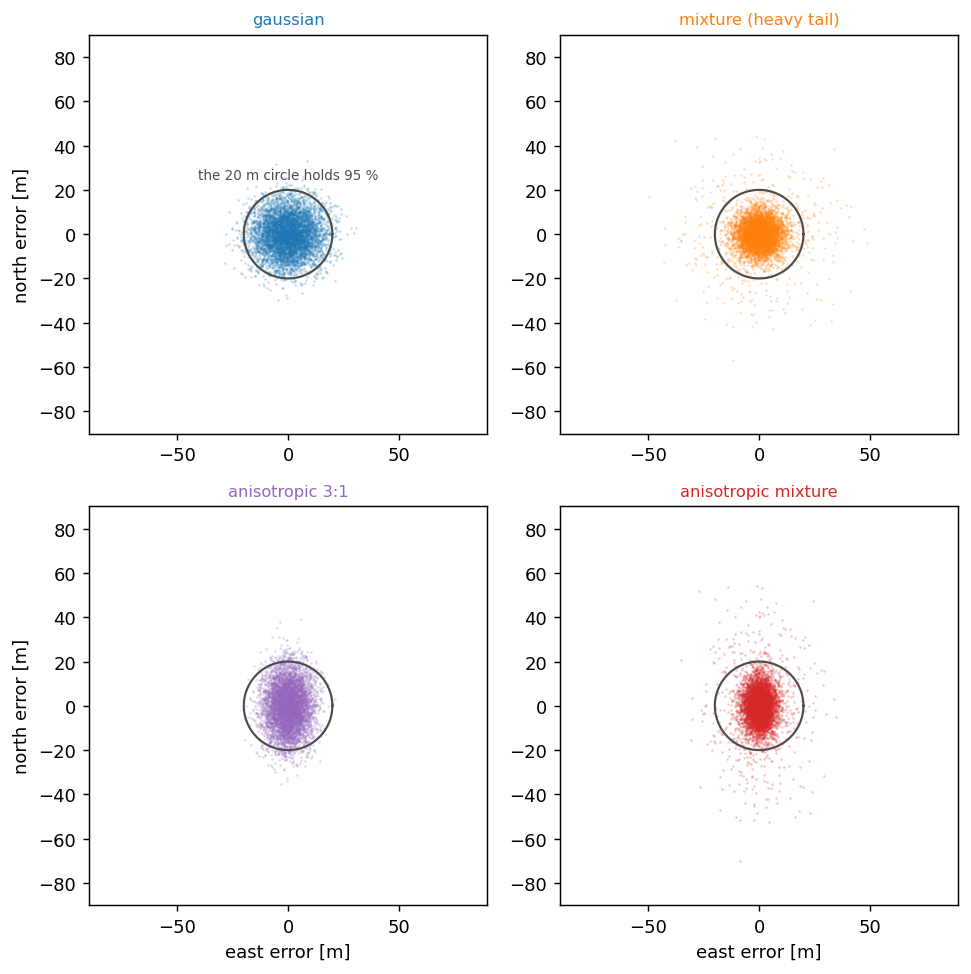

In [5]:
theta = np.linspace(0.0, 2.0 * np.pi, 240)
fig, axes = plt.subplots(2, 2, figsize=(7.6, 7.6))
for ax, (label, _, colour) in zip(axes.ravel(), SHAPES):
    pts = samples[label]
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.25, color=colour, linewidth=0)
    ax.plot(POS_CI95 * np.cos(theta), POS_CI95 * np.sin(theta), lw=1.2, color="0.3")
    ax.set_aspect("equal")
    ax.set_xlim(-90, 90)
    ax.set_ylim(-90, 90)
    ax.set_title(label, fontsize=9, color=colour)
for ax in axes[1]:
    ax.set_xlabel("east error [m]")
for ax in axes[:, 0]:
    ax.set_ylabel("north error [m]")
axes[0, 0].annotate(f"the {POS_CI95:.0f} m circle holds 95 %", (0, POS_CI95), (0, 6),
                    textcoords="offset points", ha="center", fontsize=7.5, color="0.3")
fig.tight_layout()

## 5. Declare an accuracy that is not the truth

The error is drawn from the aircraft's **actual** accuracy. The broadcast carries its **declared**
one. They are the same number unless you say otherwise.

Set them apart with `pos_ci95_declared` / `vel_ci95_declared`. A receiver that sizes its own margin
from the declared value then works from a number that is wrong — which is the integrity failure that
receiver-autonomous integrity monitoring exists to catch.

In [6]:
print(f"{'aircraft':<12}{'true ci95':>11}{'declared':>11}{'error drawn':>14}{'broadcast says':>17}")
for label, declared in (("honest", None), ("boastful", 5.0), ("cautious", 60.0)):
    ac = dataclasses.replace(TRUE, pos_ci95_declared=declared)
    m = nav.measure(nav.initial_state(), ac, 0.0, rng(11))
    shown = "same" if declared is None else f"{declared:.0f} m"
    print(f"{label:<12}{ac.pos_ci95:>9.0f} m{shown:>11}{error_metres(ac, m.state):>12.2f} m"
          f"{m.state.pos_ci95:>15.0f} m")

aircraft      true ci95   declared   error drawn   broadcast says
honest             20 m       same       11.11 m             20 m
boastful           20 m        5 m       11.11 m              5 m
cautious           20 m       60 m       11.11 m             60 m


## 6. Write your own shape

A `NoiseDistribution` is a plain function:

```python
def my_error(rng, ci95) -> tuple[float, float]: ...
```

Three rules, and the last is the one that matters:

1. Draw everything from the `rng` you are given. Never from a global.
2. Reuse **one** generator across the draws. A new generator from the same seed for each draw
   returns the same number every time. Section 3 and section 4 both make this explicit.
3. Hold the containment. 95 % of the draws must land inside `ci95`.

Test the containment before you use it. A shape that does not hold it makes every comparison against
the built-in shapes meaningless.

In [7]:
def uniform_disc(rng_, ci95: float) -> tuple[float, float]:
    """Uniform inside a disc, scaled so that 95 % of the draws land inside ci95."""
    radius = ci95 / np.sqrt(0.95)                     # area scaling: P(r <= ci95) = 0.95
    r = radius * np.sqrt(rng_.uniform())
    a = rng_.uniform(0.0, 2.0 * np.pi)
    return float(r * np.cos(a)), float(r * np.sin(a))


stream = rng(21)
pts = np.array([uniform_disc(stream, POS_CI95) for _ in range(8000)])
radius = np.hypot(pts[:, 0], pts[:, 1])
print(f"my shape: inside ci95 {(radius <= POS_CI95).mean():.3f}   (must be about 0.950)")

model = GnssNavigation(pos_distribution=uniform_disc)
m = model.measure(model.initial_state(), TRUE, 0.0, rng(0))
print(f"it plugs straight in: off by {error_metres(TRUE, m.state):.2f} m")

my shape: inside ci95 0.950   (must be about 0.950)
it plugs straight in: off by 16.38 m


## Do it yourself

1. Set `tail_weight=0.3` on the mixture. Check that the containment still holds, and compare the
   worst draw.
2. Give position and velocity **different** shapes in one `GnssNavigation`.
3. Write a shape with a bias (a non-zero mean). Check what it does to the containment.
4. Set `vel_ci95=5.0` and measure. Compare the measured `trk` with the true one.

## Check

1. Why is the accuracy a field of the aircraft and not a constructor argument of the model?
2. All four shapes hold the same 95 % containment. Why is that necessary for a fair comparison?
3. `pos_ci95_declared=5.0` on an aircraft whose true accuracy is 20 m. Which number does the error
   come from, and which one does the receiver read?

## Next

`L1.13 — Navigation degradation`. A per-step draw has no memory. Next you add an error that lasts.